In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42

## Load Data

In [2]:
df = pd.read_csv(r"D://adity//aoml_project//hotel_bookings.csv")
print('Shape:', df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
print(df.isnull().sum()[df.isnull().sum() > 0])

children         4
country        488
agent        16340
company     112593
dtype: int64


In [6]:
df.fillna(0, inplace=True)
invalid = (df.children == 0) & (df.adults == 0) & (df.babies == 0)
df = df[~invalid].reset_index(drop=True)
print('Shape: ', df.shape)

Shape:  (119210, 32)


In [63]:
print('Duplicates found:', df.duplicated().sum())

Duplicates found: 35989


In [19]:
num_cols_outlier = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_outlier = [c for c in num_cols_outlier if c != 'is_canceled']

outlier_summary = {}
for col in num_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = count

outlier_series = pd.Series(outlier_summary).sort_values(ascending=False)
print(outlier_series[outlier_series > 0])


adults                            29530
booking_changes                   17978
children                           8590
required_car_parking_spaces        7409
company                            6768
previous_cancellations             6479
adr                                3864
is_repeated_guest                  3755
days_in_waiting_list               3693
previous_bookings_not_canceled     3613
stays_in_week_nights               3330
lead_time                          2981
total_of_special_requests          2874
agent                              1251
babies                              917
stays_in_weekend_nights             258
dtype: int64


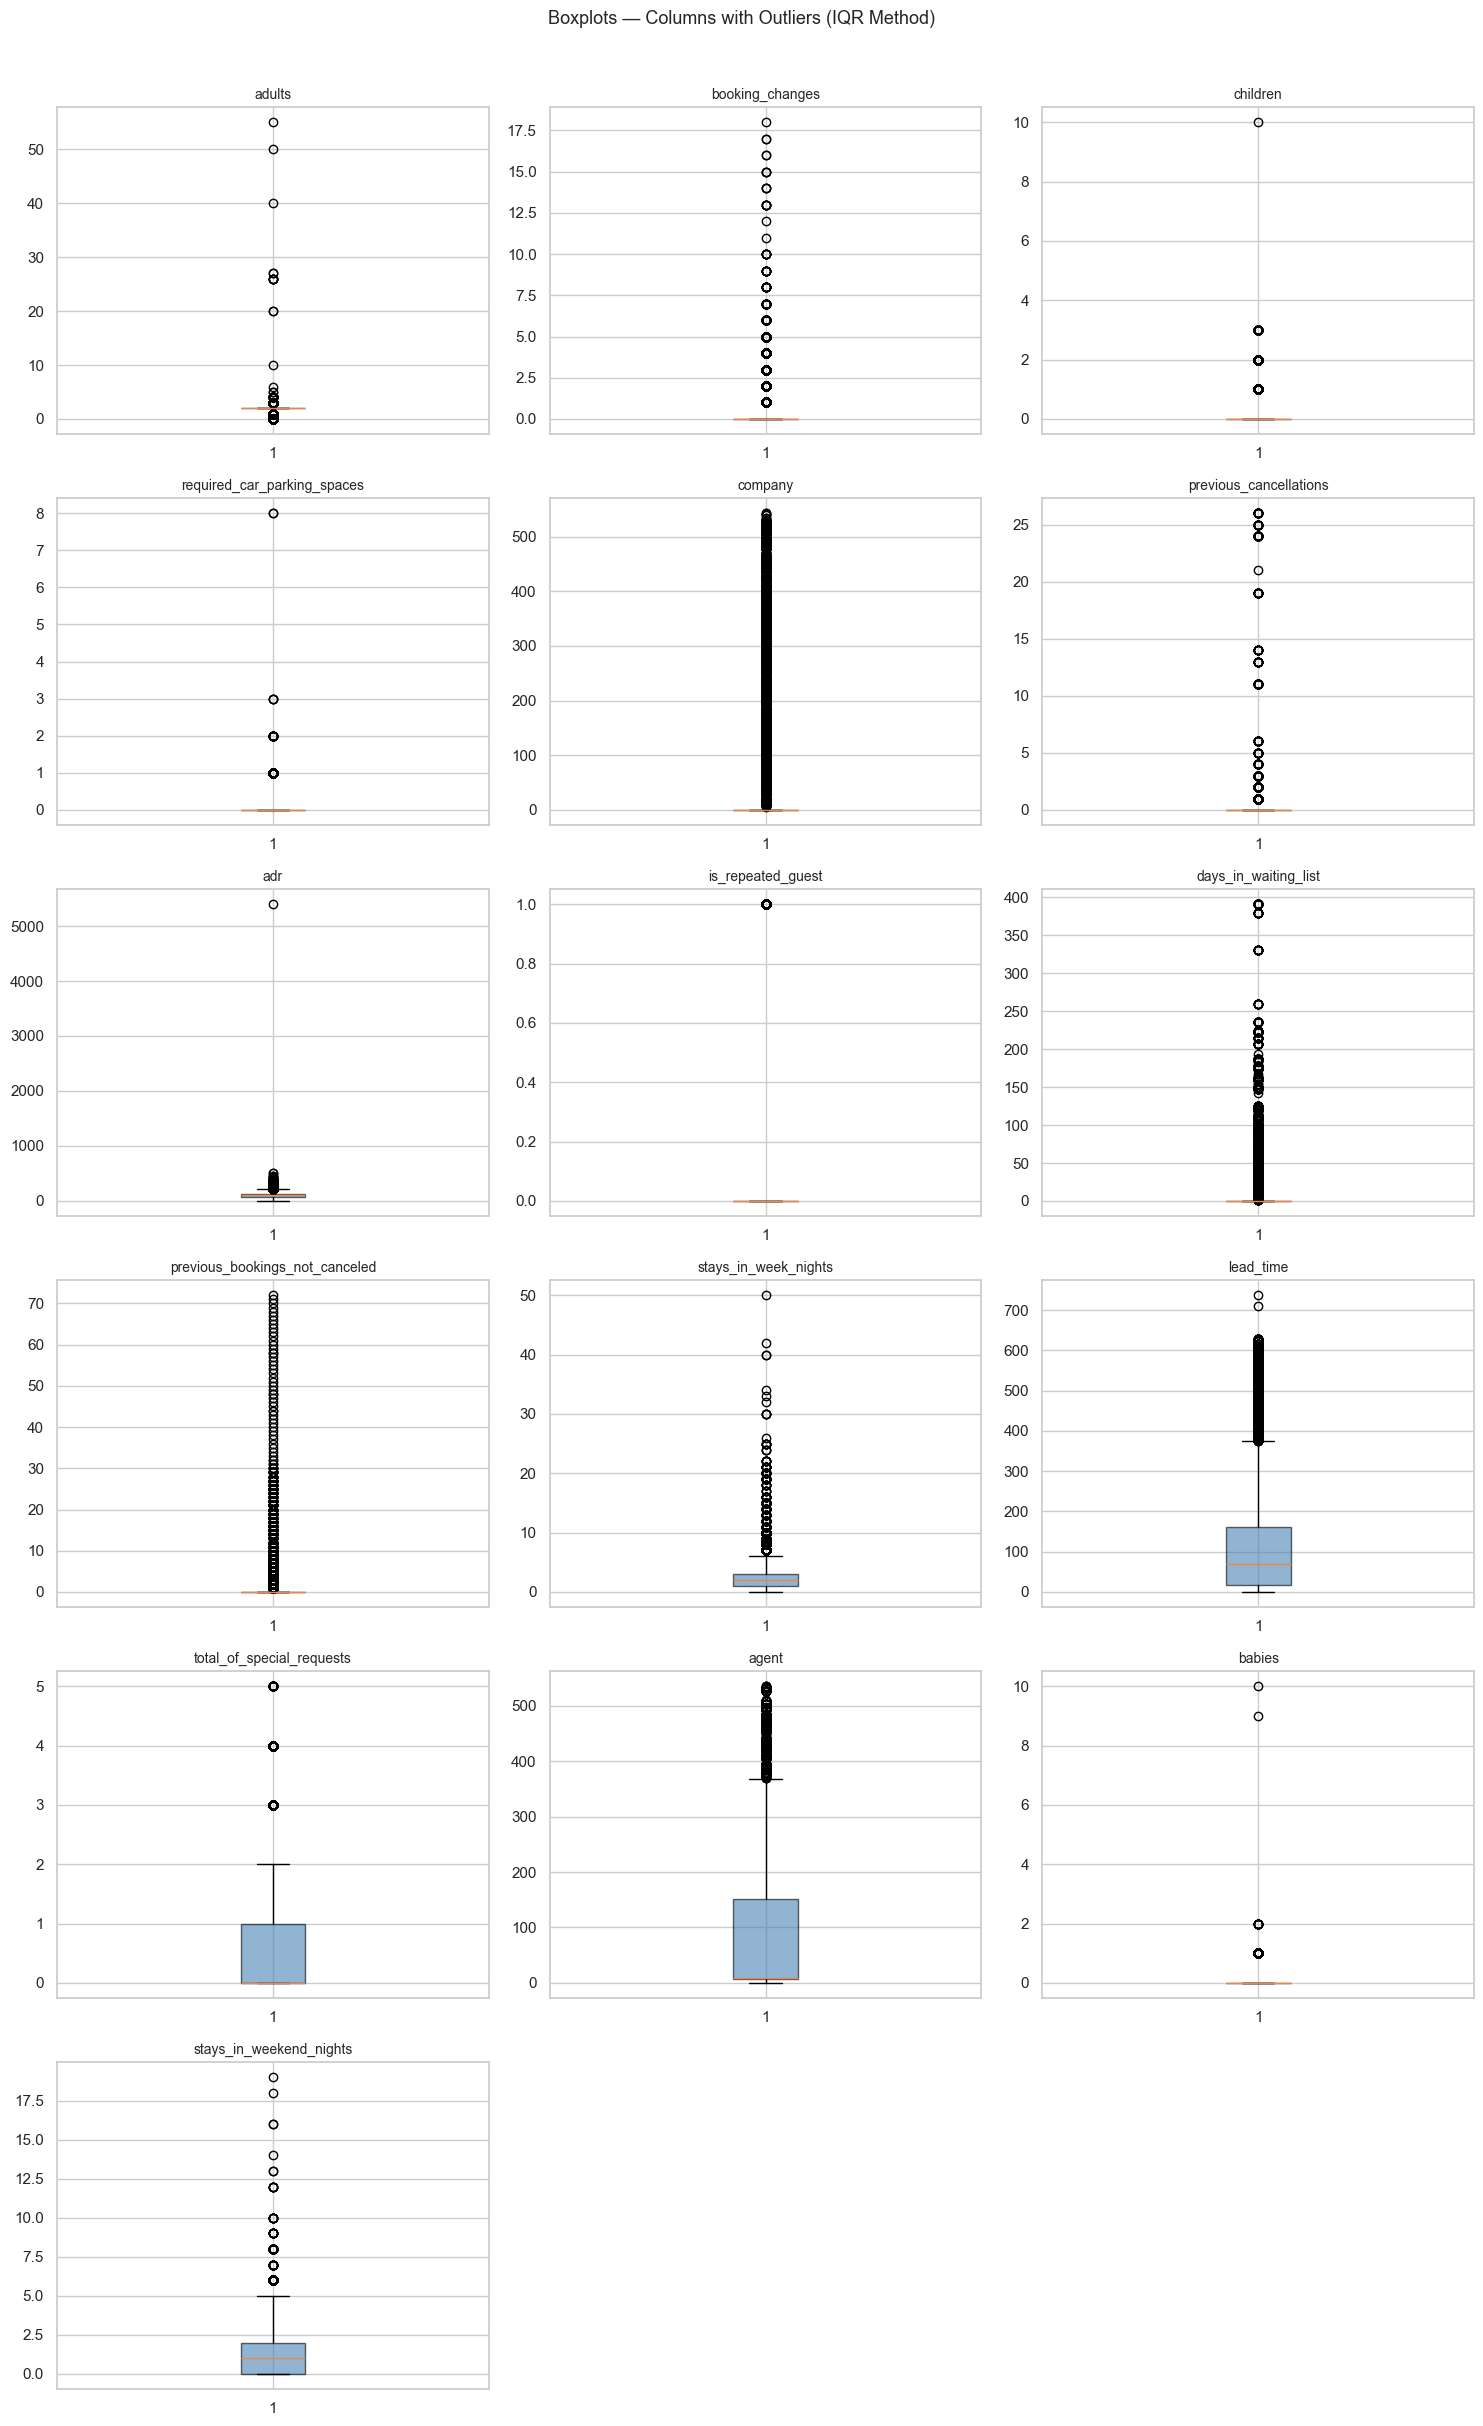

In [20]:
cols_with_outliers = outlier_series[outlier_series > 0].index.tolist()

n = len(cols_with_outliers)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots — Columns with Outliers (IQR Method)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
df.shape

(119210, 32)

## EDA

In [7]:
#Country 
countryguests = df[df['is_canceled'] == 0]['country'].value_counts().reset_index()
countryguests.columns = ['country', 'No of guests']
countryguests.head(10)

,country,No of guests
0,PRT,20977
1,GBR,9668
2,FRA,8468
3,ESP,6383
4,DEU,6067
5,IRL,2542
6,ITA,2428
7,BEL,1868
8,NLD,1716
9,USA,1592


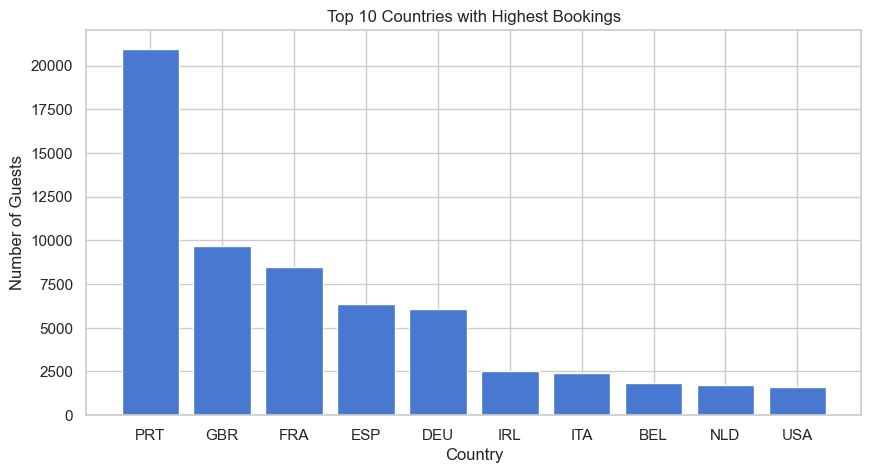

In [8]:
top10 = countryguests.sort_values(by='No of guests', ascending=False).head(10)

plt.figure()
plt.bar(top10['country'], top10['No of guests'])
plt.xlabel('Country')
plt.ylabel('Number of Guests')
plt.title('Top 10 Countries with Highest Bookings')
plt.show()

In [9]:
data_resort = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]
data_city   = df[(df['hotel'] == 'City Hotel')   & (df['is_canceled'] == 0)]

print('Number of Resort Hotel bookings:', len(data_resort))
print('Number of City Hotel bookings  :', len(data_city))

Number of Resort Hotel bookings: 28927
Number of City Hotel bookings  : 46084


In [10]:
resort_hotel = data_resort.groupby('arrival_date_month')['adr'].mean().reset_index()
city_hotel   = data_city.groupby('arrival_date_month')['adr'].mean().reset_index()

final_hotel = resort_hotel.merge(city_hotel, on='arrival_date_month')
final_hotel.columns = ['month', 'price_for_resort', 'price_for_city_hotel']

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
final_hotel['month'] = pd.Categorical(final_hotel['month'], categories=month_order, ordered=True)
final_hotel = final_hotel.sort_values('month')
final_hotel

,month,price_for_resort,price_for_city_hotel
4,January,48.761125,82.330983
3,February,54.147478,86.520062
7,March,57.056838,90.658533
0,April,75.867816,111.962267
8,May,76.657558,120.669827
6,June,107.974850,117.874360
5,July,150.122528,115.818019
1,August,181.205892,118.674598
11,September,96.416860,112.776582
10,October,61.775449,102.004672


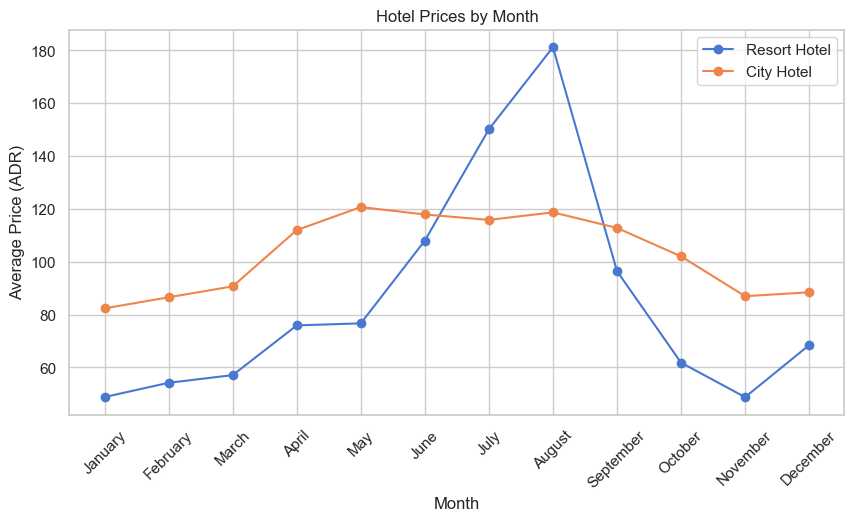

In [11]:
plt.figure()
plt.plot(final_hotel['month'], final_hotel['price_for_resort'], marker='o', label='Resort Hotel')
plt.plot(final_hotel['month'], final_hotel['price_for_city_hotel'], marker='o', label='City Hotel')
plt.xlabel('Month')
plt.ylabel('Average Price (ADR)')
plt.title('Hotel Prices by Month')
plt.xticks(rotation=45)
plt.legend()
plt.show()

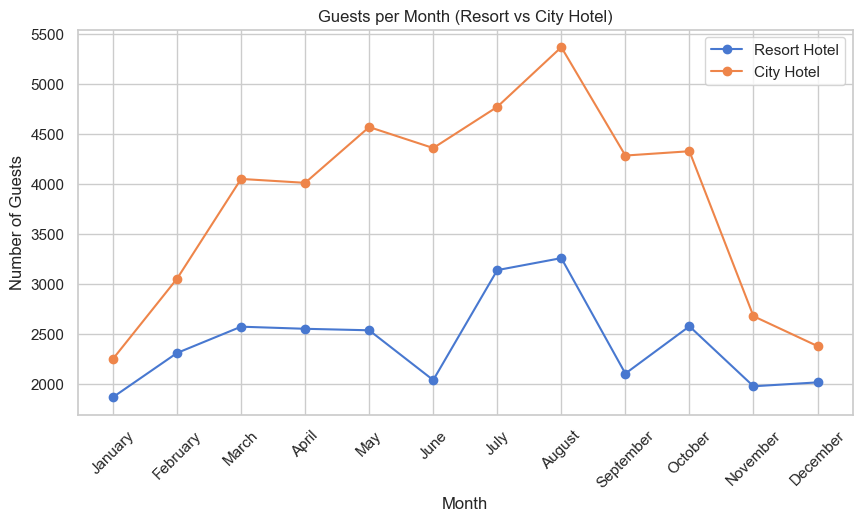

In [12]:
resort_guests = data_resort['arrival_date_month'].value_counts().reset_index()
resort_guests.columns = ['month', 'no of guests']
city_guests = data_city['arrival_date_month'].value_counts().reset_index()
city_guests.columns = ['month', 'no of guests']

final_guests = resort_guests.merge(city_guests, on='month')
final_guests.columns = ['month', 'no of guests in resort', 'no of guests in city hotel']

final_guests['month'] = pd.Categorical(final_guests['month'], categories=month_order, ordered=True)
final_guests = final_guests.sort_values('month')

plt.figure(figsize=(10, 5))
plt.plot(final_guests['month'], final_guests['no of guests in resort'], marker='o', label='Resort Hotel')
plt.plot(final_guests['month'], final_guests['no of guests in city hotel'], marker='o', label='City Hotel')
plt.xlabel('Month')
plt.ylabel('Number of Guests')
plt.title('Guests per Month (Resort vs City Hotel)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

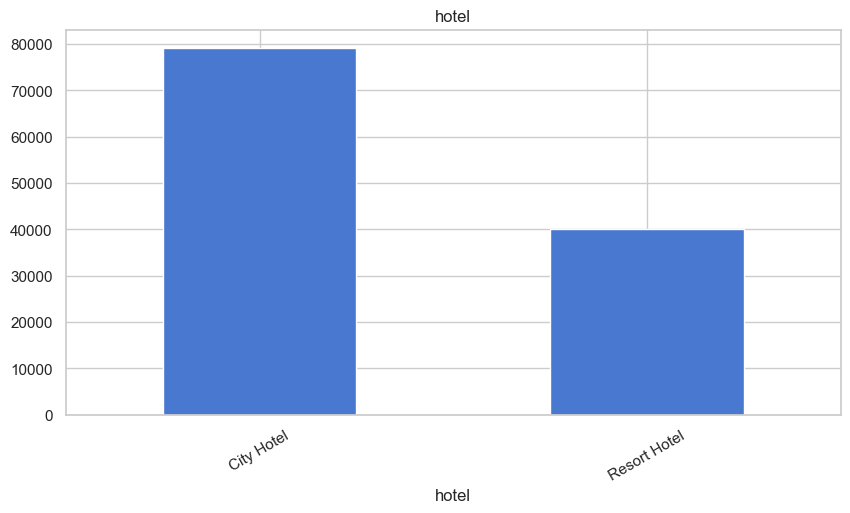

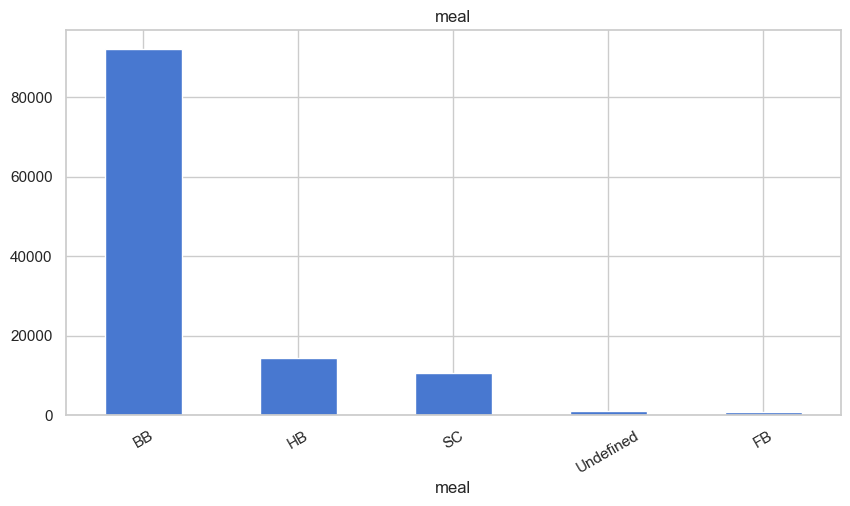

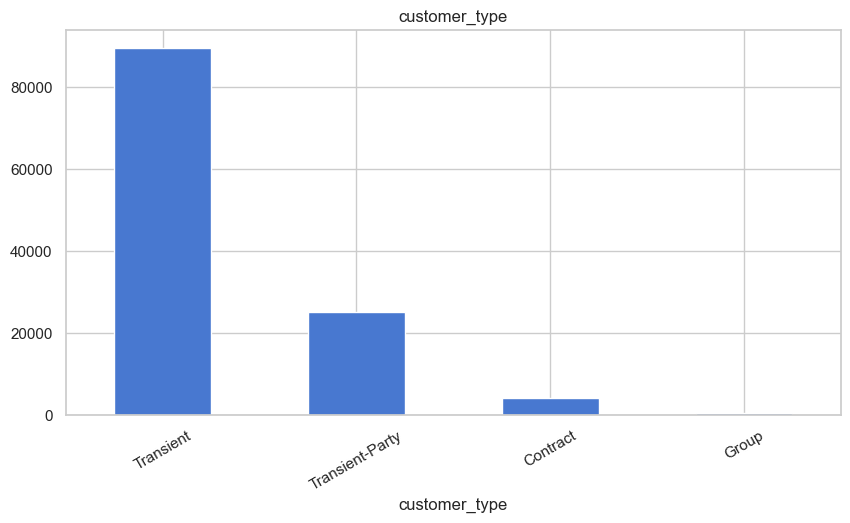

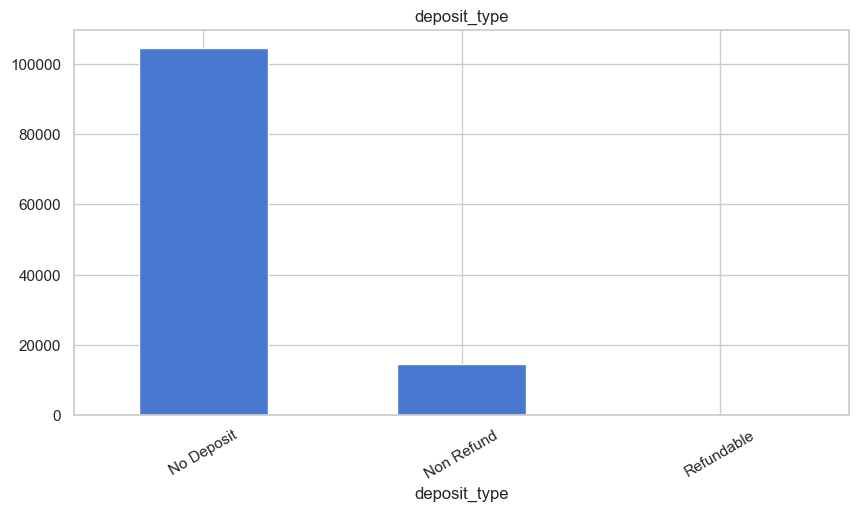

In [13]:
for col in ['hotel', 'meal', 'customer_type', 'deposit_type']:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=30)
    plt.show()

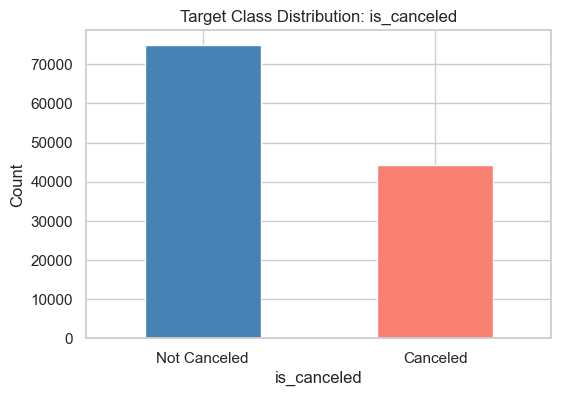

is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Class Distribution: is_canceled')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'], rotation=0)
plt.ylabel('Count')
plt.show()
print(df['is_canceled'].value_counts(normalize=True).round(3))

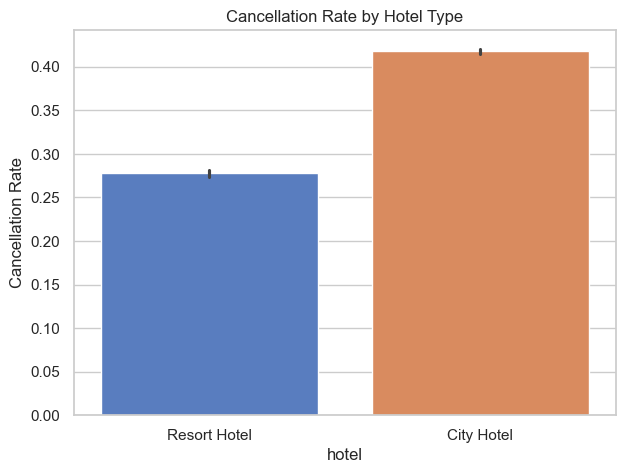

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(x='hotel', y='is_canceled', data=df, palette='muted')
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate')
plt.show()

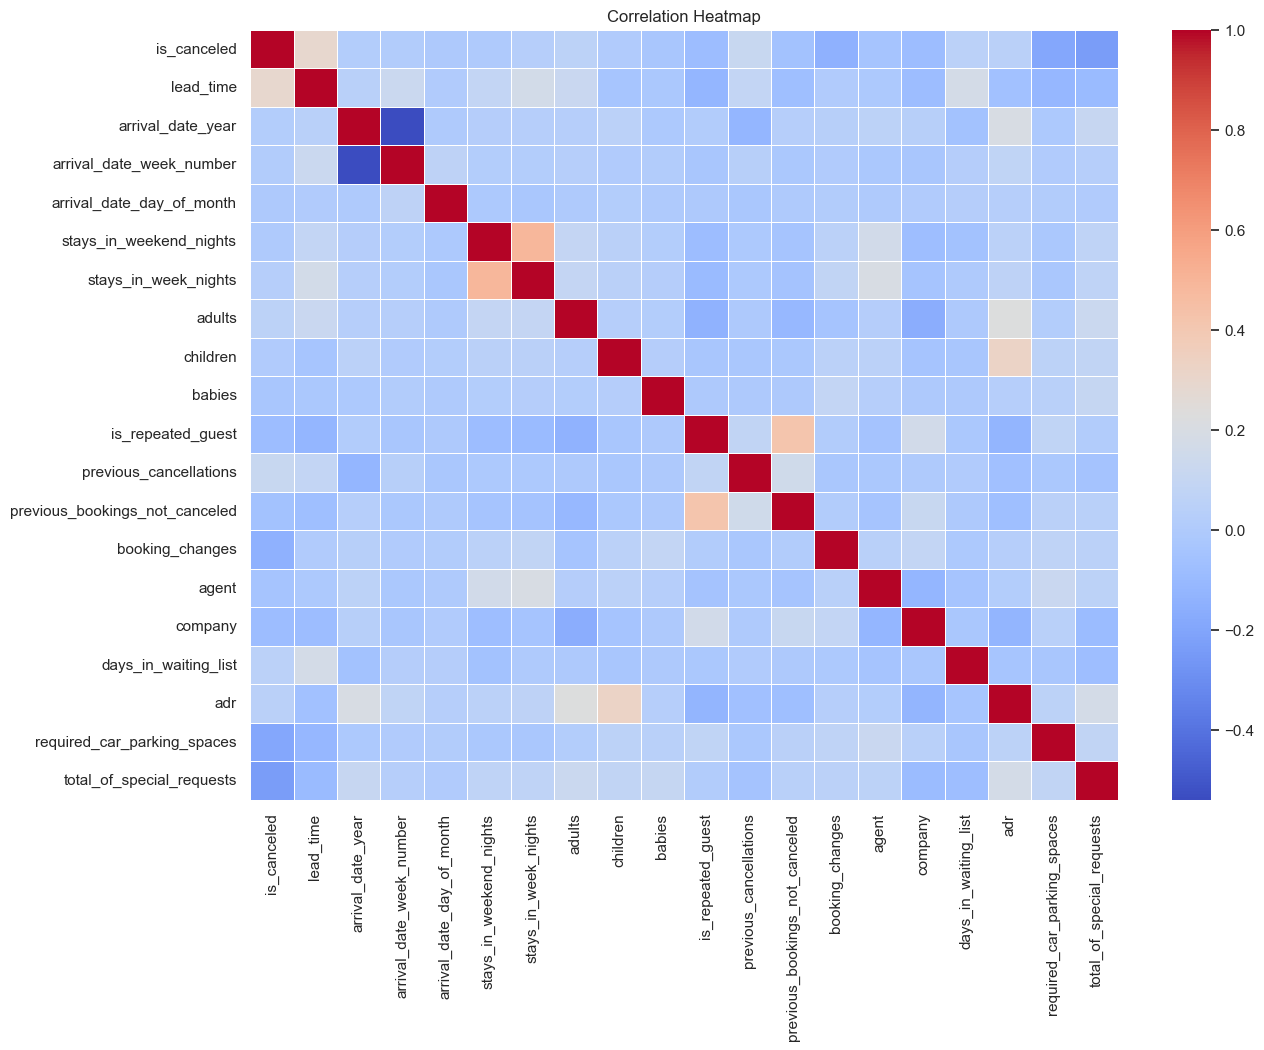

In [16]:
num_df_eda = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(num_df_eda.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
correlation = num_df_eda.corr()['is_canceled'].abs().sort_values(ascending=False)
print(correlation)

is_canceled                       1.000000
lead_time                         0.292876
total_of_special_requests         0.234877
required_car_parking_spaces       0.195701
booking_changes                   0.144832
previous_cancellations            0.110139
is_repeated_guest                 0.083745
company                           0.083594
adults                            0.058182
previous_bookings_not_canceled    0.057365
days_in_waiting_list              0.054301
agent                             0.046770
adr                               0.046492
babies                            0.032569
stays_in_week_nights              0.025542
arrival_date_year                 0.016622
arrival_date_week_number          0.008315
arrival_date_day_of_month         0.005948
children                          0.004851
stays_in_weekend_nights           0.001323
Name: is_canceled, dtype: float64


<Figure size 1000x500 with 0 Axes>

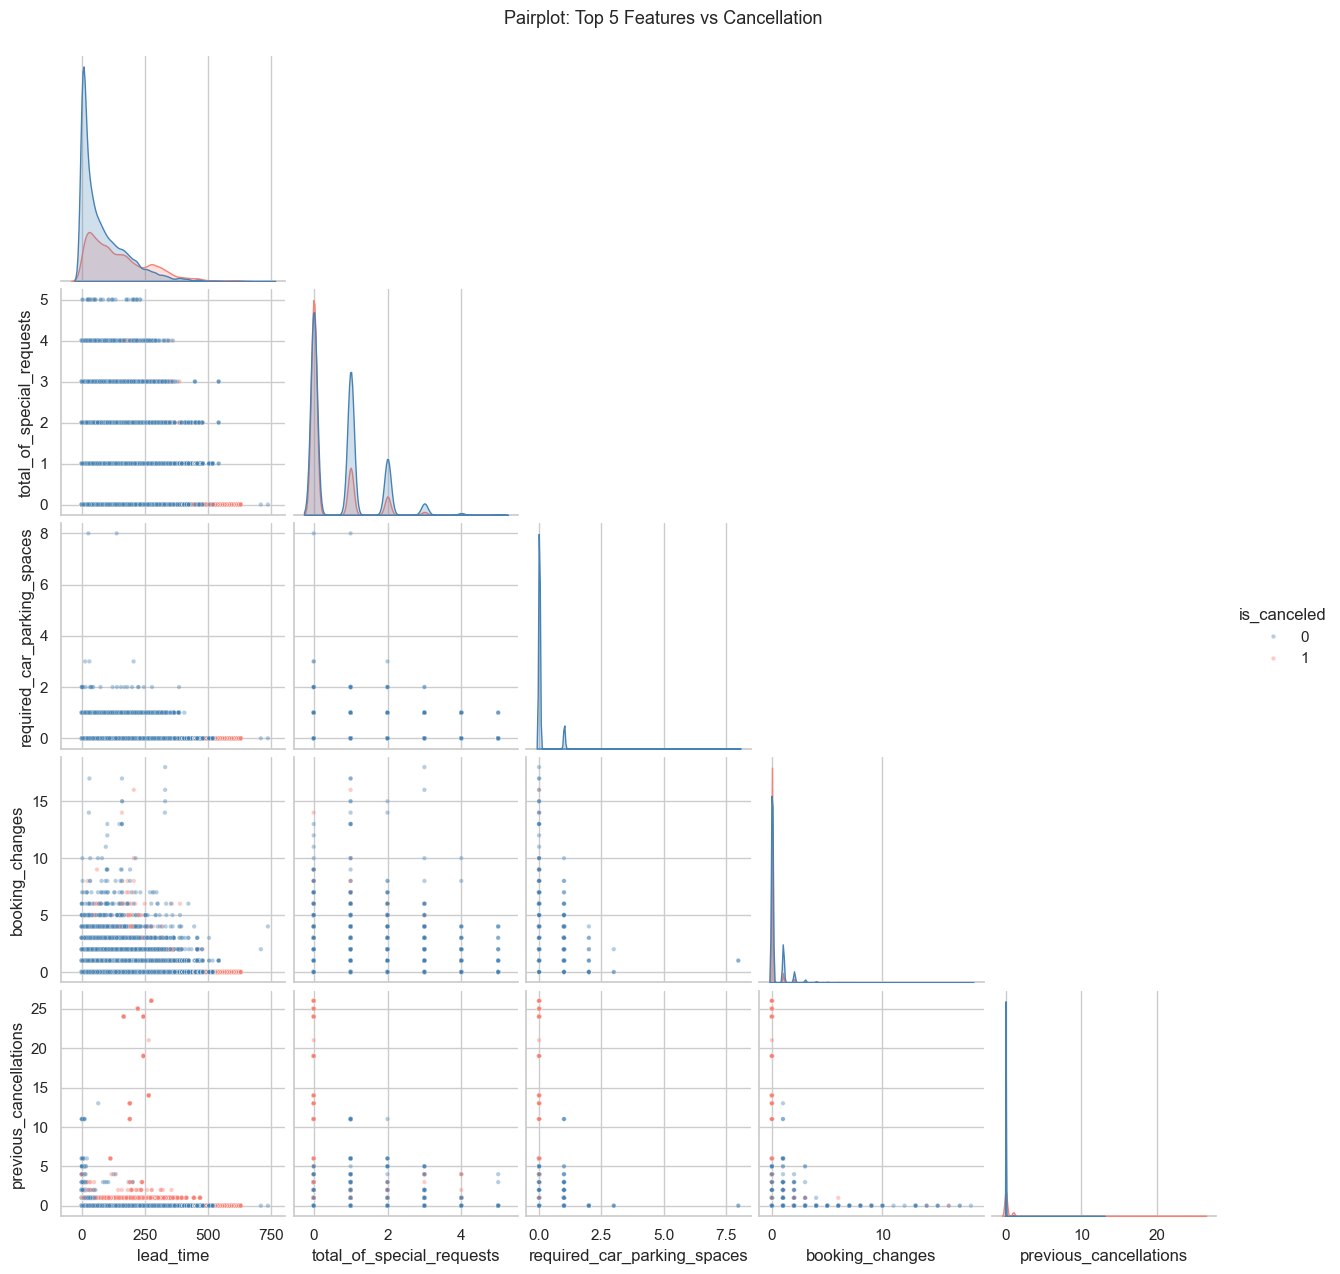

In [18]:
top_corr_features = (
    num_df_eda.corr()['is_canceled']
    .abs()
    .sort_values(ascending=False)
    .index[1:6]
    .tolist()
)

pairplot_cols = top_corr_features + ['is_canceled']
pairplot_df = num_df_eda[pairplot_cols].copy()

plt.figure()
sns.pairplot(
    pairplot_df,
    hue='is_canceled',
    palette={0: 'steelblue', 1: 'salmon'},
    plot_kws={'alpha': 0.4, 's': 10},
    diag_kind='kde',
    corner=True       # cleaner — avoids redundant upper triangle
)
plt.suptitle('Pairplot: Top 5 Features vs Cancellation', y=1.02, fontsize=13)
plt.show()

=== Skewness of Numeric Features ===
babies                            24.627962
previous_cancellations            24.443924
previous_bookings_not_canceled    23.539555
adults                            18.774333
days_in_waiting_list              11.948868
adr                               10.612728
company                            5.929276
booking_changes                    5.500058
is_repeated_guest                  5.364723
required_car_parking_spaces        4.162345
children                           4.109048
stays_in_week_nights               2.754863
total_of_special_requests          1.349049
lead_time                          1.345809
stays_in_weekend_nights            1.320242
agent                              1.298545
is_canceled                        0.535127
arrival_date_day_of_month         -0.002111
arrival_date_week_number          -0.010199
arrival_date_year                 -0.232458
dtype: float64


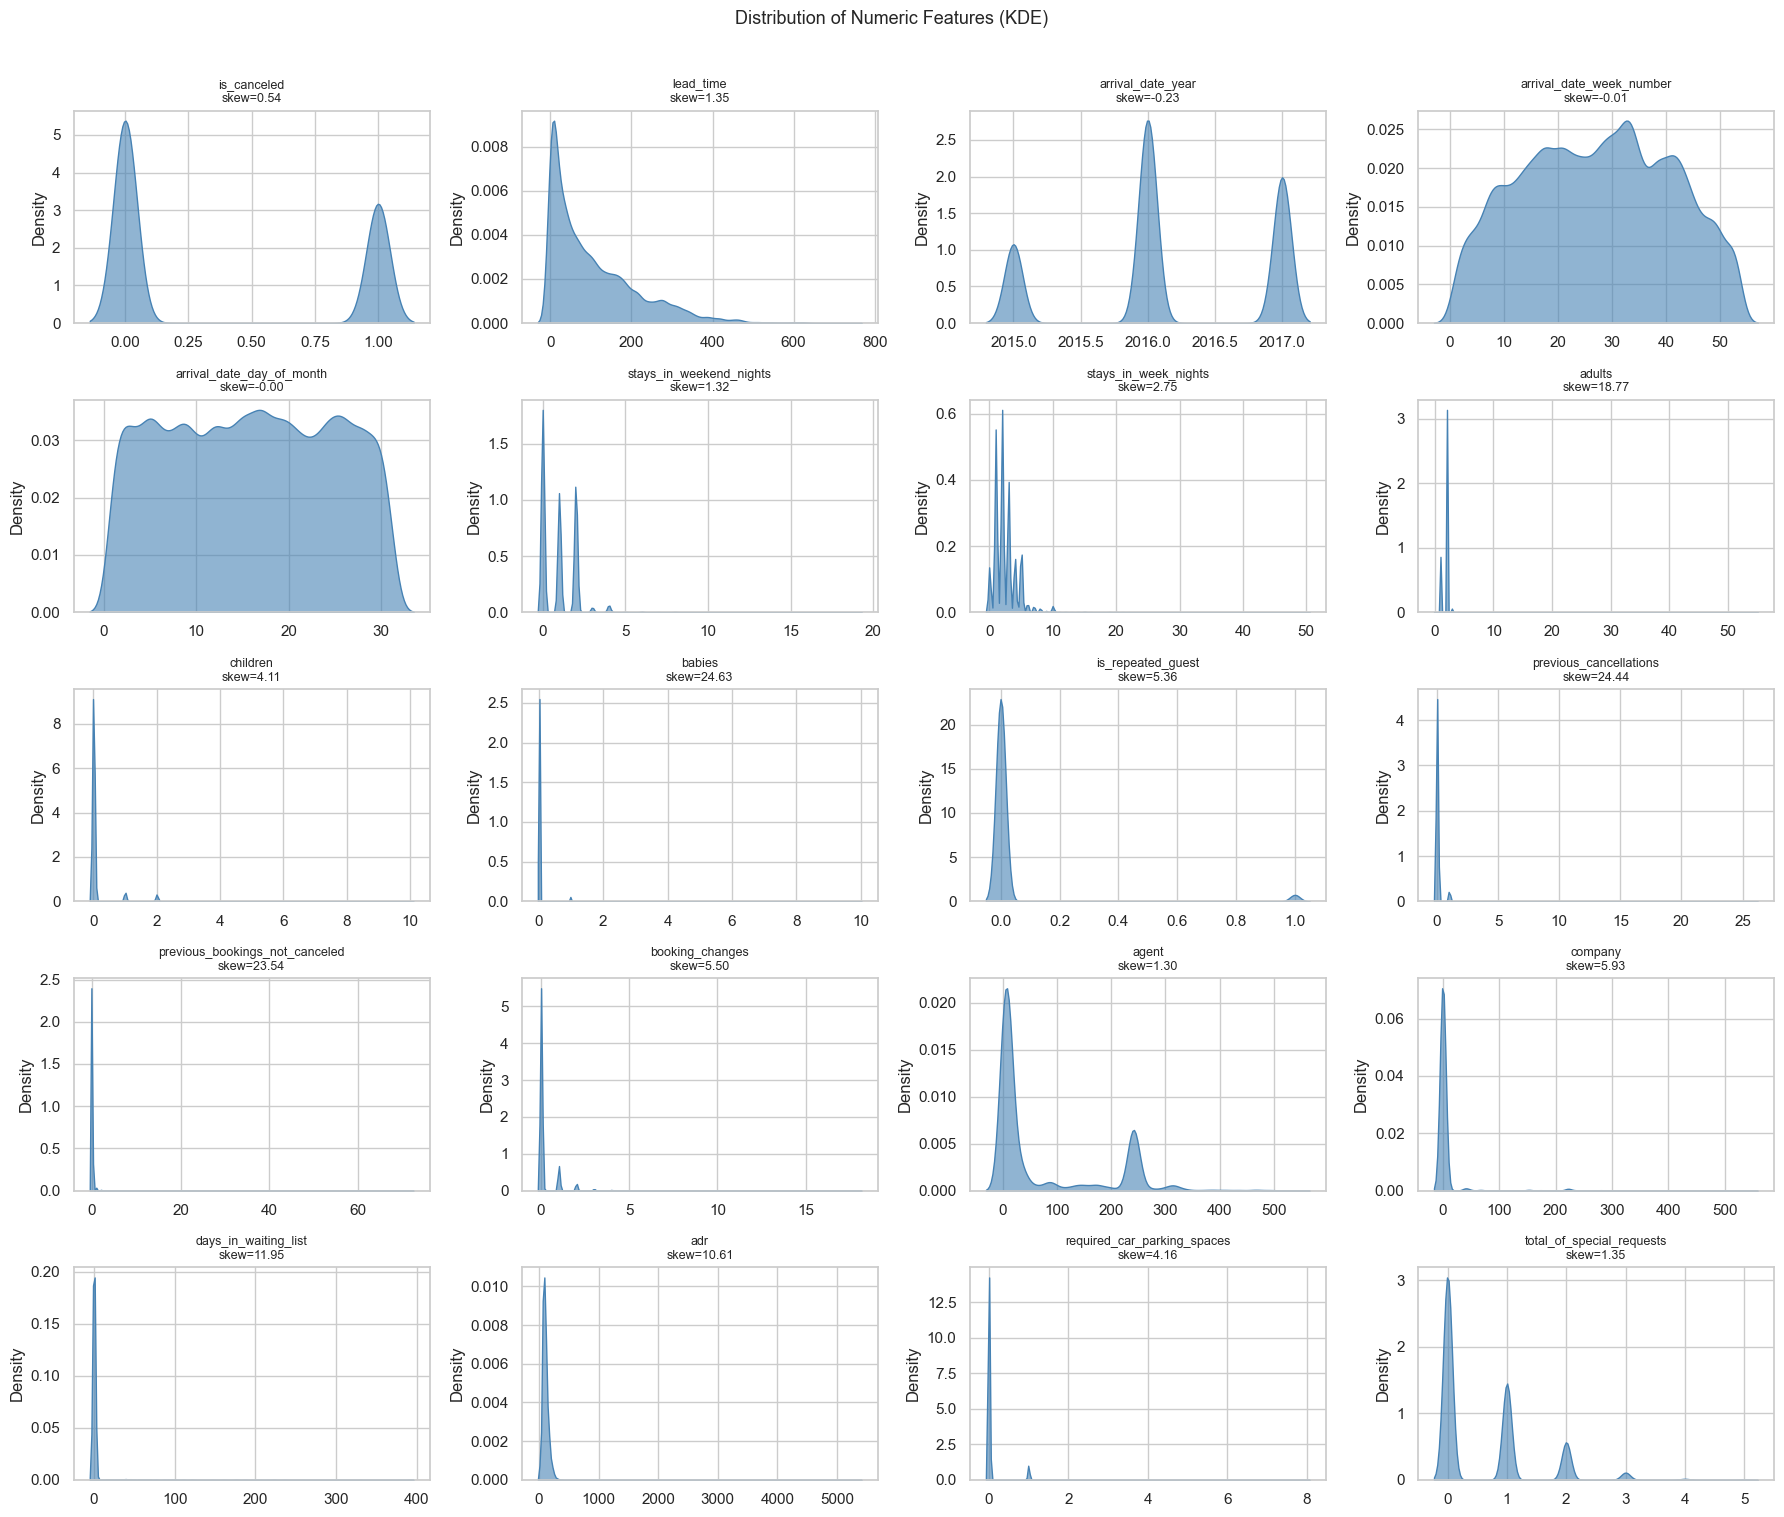

In [ ]:
skewness = num_df_eda.skew().sort_values(ascending=False)
print("=== Skewness of Numeric Features ===")
print(skewness)

n = len(num_df_eda.columns)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_df_eda.columns):
    sns.kdeplot(num_df_eda[col], ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(f'{col}\nskew={skewness[col]:.2f}', fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numeric Features (KDE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Feature Engineering

In [25]:
useless = [
    'days_in_waiting_list',
    'arrival_date_year',
    'assigned_room_type',
    'booking_changes',
    'reservation_status',         
    'reservation_status_date',
    'country',
]

df.drop(columns=useless, inplace=True)
print('Remaining columns:', df.shape[1])
print(df.columns.tolist())

Remaining columns: 25
['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [26]:
cat_cols = [col for col in df.columns if df[col].dtype == 'O']
print('Categorical columns:', cat_cols)

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']


In [ ]:
cat_df = df[cat_cols].copy()
cat_df.drop(columns=['arrival_date_month'], inplace=True)
print('Categorical columns after drop:', cat_df.columns.tolist())

Categorical columns after drop: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']


In [30]:
for col in cat_df.columns:
    print(f"{col}: {cat_df[col].unique()}\n")

hotel: ['Resort Hotel' 'City Hotel']

meal: ['BB' 'FB' 'HB' 'SC' 'Undefined']

market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation']

distribution_channel: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']

reserved_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'B']

deposit_type: ['No Deposit' 'Refundable' 'Non Refund']

customer_type: ['Transient' 'Contract' 'Transient-Party' 'Group']



In [31]:
cat_df['hotel'] = cat_df['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})

cat_df['meal'] = cat_df['meal'].map({'BB': 0, 'FB': 1, 'HB': 2, 'SC': 3, 'Undefined': 4})

cat_df['market_segment'] = cat_df['market_segment'].map({
    'Direct': 0, 'Corporate': 1, 'Online TA': 2, 'Offline TA/TO': 3,
    'Complementary': 4, 'Groups': 5, 'Undefined': 6, 'Aviation': 7
})

cat_df['distribution_channel'] = cat_df['distribution_channel'].map({
    'Direct': 0, 'Corporate': 1, 'TA/TO': 2, 'Undefined': 3, 'GDS': 4
})

cat_df['reserved_room_type'] = cat_df['reserved_room_type'].map({
    'C': 0, 'A': 1, 'D': 2, 'E': 3, 'G': 4, 'F': 5, 'H': 6, 'L': 7, 'B': 8
})

cat_df['deposit_type'] = cat_df['deposit_type'].map({
    'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2
})

cat_df['customer_type'] = cat_df['customer_type'].map({
    'Transient': 0, 'Contract': 1, 'Transient-Party': 2, 'Group': 3
})

print('Any NaN after encoding?', cat_df.isnull().sum().sum())
cat_df.head()

Any NaN after encoding? 0


,hotel,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0
3,0,0,1,1,1,0,0
4,0,0,2,2,1,0,0


In [33]:
num_df = df.drop(columns=cat_cols).drop(columns=['is_canceled'])

num_df['adr'] = num_df['adr'].clip(lower=0)

for col in ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'agent', 'company', 'adr']:
    num_df[col] = np.log1p(num_df[col])

print('NaN after log transform:', num_df.isnull().sum().sum())
num_df.head()

NaN after log transform: 0


,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,agent,company,adr,required_car_parking_spaces,total_of_special_requests
0,5.837730,3.332205,0.693147,0,0,2,0.0,0,0,0,0,0.000000,0.0,0.000000,0,0
1,6.603944,3.332205,0.693147,0,0,2,0.0,0,0,0,0,0.000000,0.0,0.000000,0,0
2,2.079442,3.332205,0.693147,0,1,1,0.0,0,0,0,0,0.000000,0.0,4.330733,0,0
3,2.639057,3.332205,0.693147,0,1,1,0.0,0,0,0,0,5.720312,0.0,4.330733,0,0
4,2.708050,3.332205,0.693147,0,2,2,0.0,0,0,0,0,5.484797,0.0,4.595120,0,1


In [34]:
X = pd.concat([cat_df, num_df], axis=1)
y = df['is_canceled']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Any NaN in X?', X.isnull().sum().sum())
X.head()

X shape: (119210, 23)
y shape: (119210,)
Any NaN in X? 0


,hotel,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,lead_time,arrival_date_week_number,arrival_date_day_of_month,...,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,agent,company,adr,required_car_parking_spaces,total_of_special_requests
0,0,0,0,0,0,0,0,5.837730,3.332205,0.693147,...,0.0,0,0,0,0,0.000000,0.0,0.000000,0,0
1,0,0,0,0,0,0,0,6.603944,3.332205,0.693147,...,0.0,0,0,0,0,0.000000,0.0,0.000000,0,0
2,0,0,0,0,1,0,0,2.079442,3.332205,0.693147,...,0.0,0,0,0,0,0.000000,0.0,4.330733,0,0
3,0,0,1,1,1,0,0,2.639057,3.332205,0.693147,...,0.0,0,0,0,0,5.720312,0.0,4.330733,0,0
4,0,0,2,2,1,0,0,2.708050,3.332205,0.693147,...,0.0,0,0,0,0,5.484797,0.0,4.595120,0,1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (83447, 23)
Test size : (35763, 23)


In [36]:
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After  SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 52550, 1: 30897}
After  SMOTE: {0: 52550, 1: 52550}


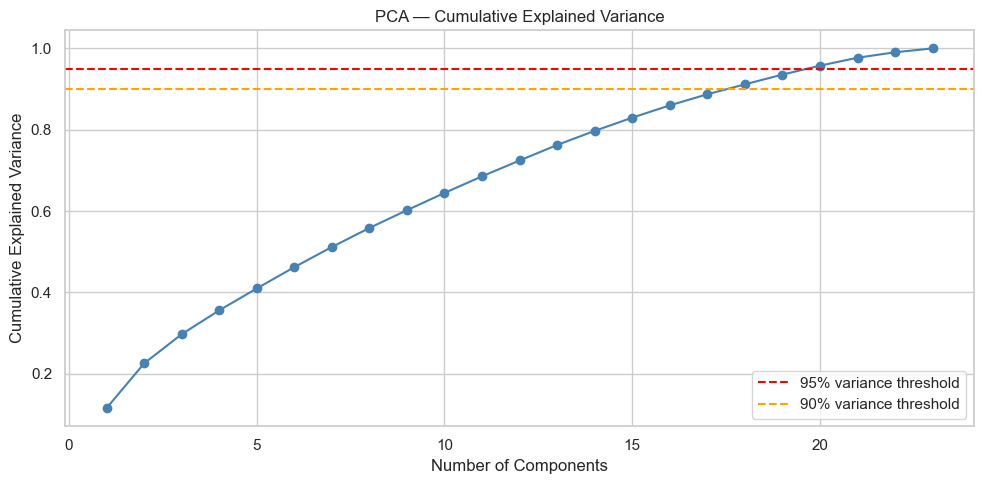

Components needed for 90% variance: 18
Components needed for 95% variance: 20


In [69]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance threshold')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f'Components needed for 90% variance: {n_components_90}')
print(f'Components needed for 95% variance: {n_components_95}')



## Classification Models

In [37]:
def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')
    if roc:
        print(f'ROC-AUC  : {roc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Not Canceled', 'Canceled'],
        ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'Confusion Matrix — {name}')

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, label=f'AUC = {roc:.3f}', color='steelblue')
        axes[1].plot([0, 1], [0, 1], 'r--')
        axes[1].set_xlabel('FPR')
        axes[1].set_ylabel('TPR')
        axes[1].set_title(f'ROC Curve — {name}')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'Model'   : name,
        'Accuracy': round(acc, 4),
        'ROC-AUC' : round(roc, 4) if roc else None
    }


===== Logistic Regression =====
Accuracy : 0.7704
ROC-AUC  : 0.8443
              precision    recall  f1-score   support

Not Canceled       0.82      0.81      0.82     22461
    Canceled       0.68      0.71      0.70     13302

    accuracy                           0.77     35763
   macro avg       0.75      0.76      0.76     35763
weighted avg       0.77      0.77      0.77     35763



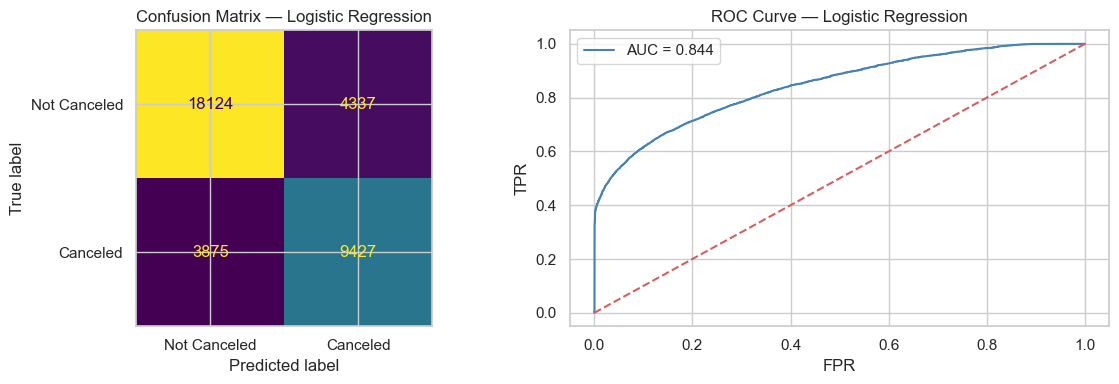

In [38]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=SEED))
])
lr.fit(X_train_res, y_train_res)
res_lr = evaluate_classifier('Logistic Regression', lr, X_test, y_test)


===== Decision Tree =====
Accuracy : 0.8153
ROC-AUC  : 0.8788
              precision    recall  f1-score   support

Not Canceled       0.83      0.89      0.86     22461
    Canceled       0.79      0.68      0.73     13302

    accuracy                           0.82     35763
   macro avg       0.81      0.79      0.80     35763
weighted avg       0.81      0.82      0.81     35763



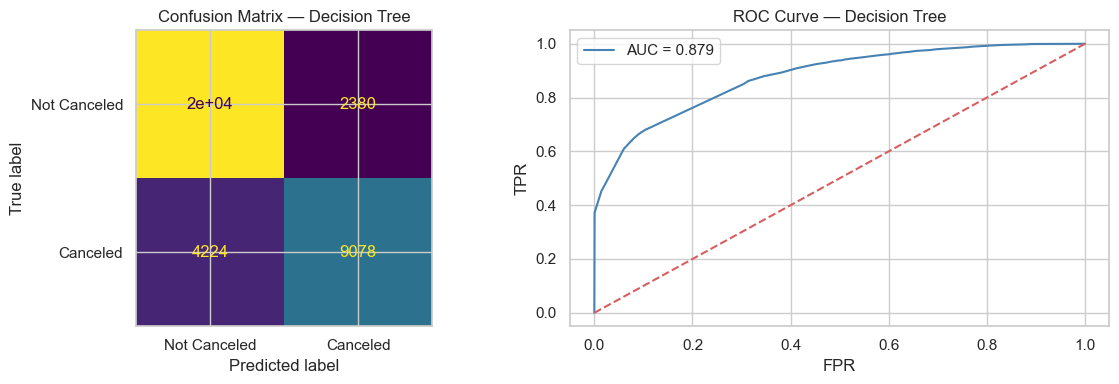

In [39]:
dt = DecisionTreeClassifier(max_depth=10, random_state=SEED)
dt.fit(X_train_res, y_train_res)
res_dt = evaluate_classifier('Decision Tree', dt, X_test, y_test)


===== Random Forest =====
Accuracy : 0.8671
ROC-AUC  : 0.9338
              precision    recall  f1-score   support

Not Canceled       0.88      0.91      0.90     22461
    Canceled       0.83      0.80      0.82     13302

    accuracy                           0.87     35763
   macro avg       0.86      0.85      0.86     35763
weighted avg       0.87      0.87      0.87     35763



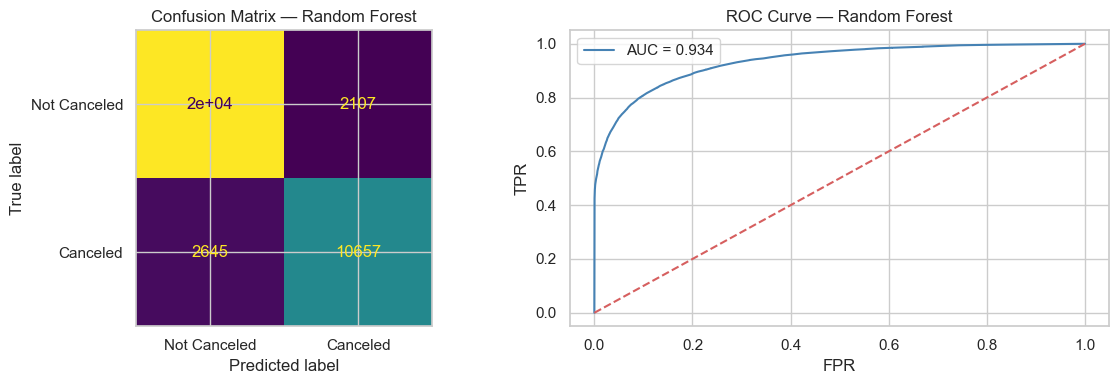

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
res_rf = evaluate_classifier('Random Forest', rf, X_test, y_test)

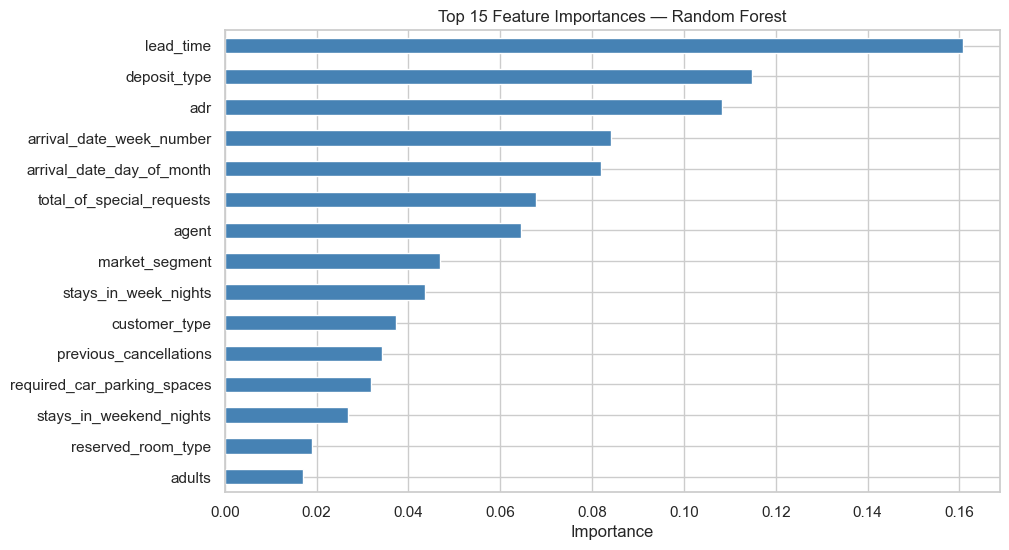

In [41]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()


===== XGBoost =====
Accuracy : 0.8304
ROC-AUC  : 0.9012
              precision    recall  f1-score   support

Not Canceled       0.85      0.88      0.87     22461
    Canceled       0.79      0.74      0.77     13302

    accuracy                           0.83     35763
   macro avg       0.82      0.81      0.82     35763
weighted avg       0.83      0.83      0.83     35763



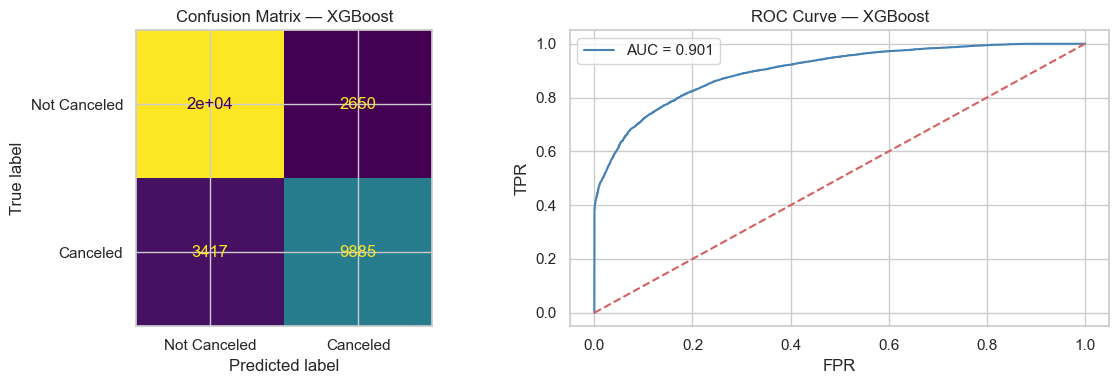

In [42]:
xgb = XGBClassifier(
    booster='gbtree', learning_rate=0.1, max_depth=5,
    n_estimators=180, random_state=SEED,
    use_label_encoder=False, eval_metric='logloss'
)
xgb.fit(X_train_res, y_train_res)
res_xgb = evaluate_classifier('XGBoost', xgb, X_test, y_test)

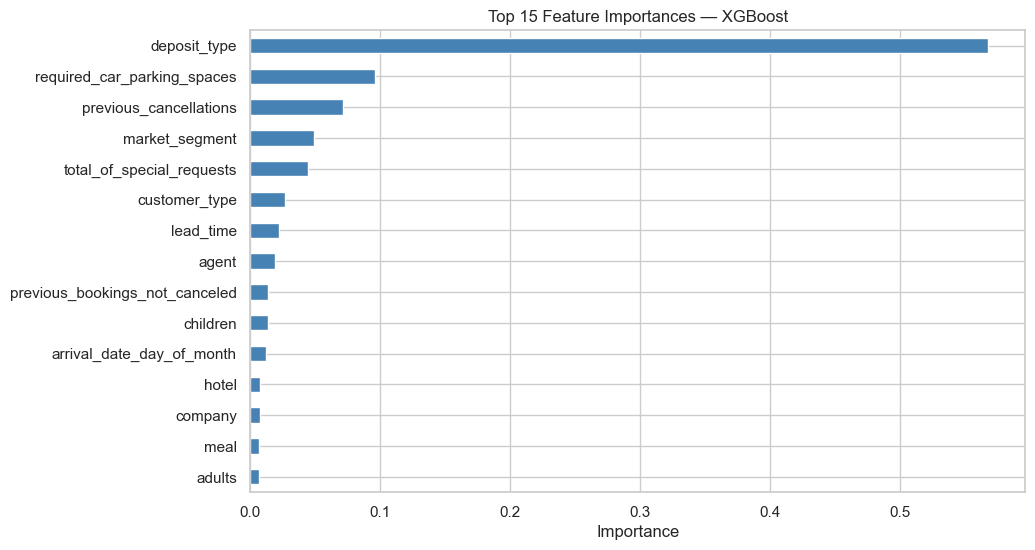

In [43]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance')
plt.show()


===== Bagging =====
Accuracy : 0.8626
ROC-AUC  : 0.9290
              precision    recall  f1-score   support

Not Canceled       0.89      0.90      0.89     22461
    Canceled       0.82      0.80      0.81     13302

    accuracy                           0.86     35763
   macro avg       0.85      0.85      0.85     35763
weighted avg       0.86      0.86      0.86     35763



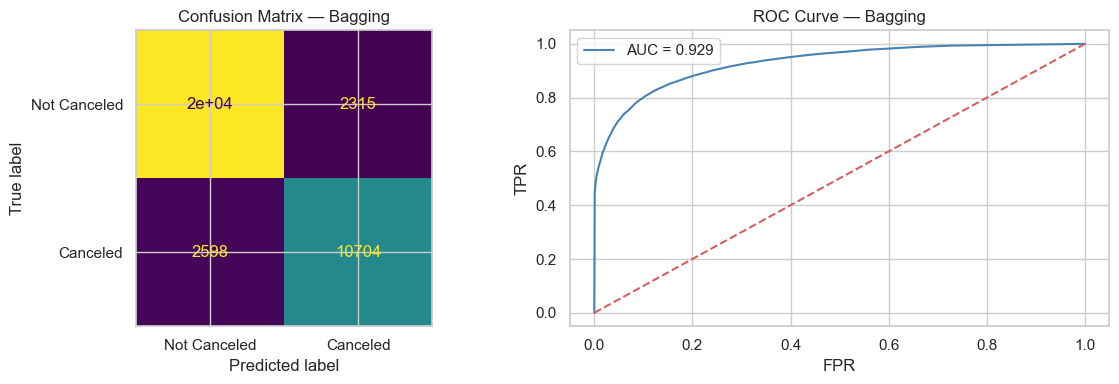

In [44]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED),
    n_estimators=50, random_state=SEED, n_jobs=-1
)
bagging.fit(X_train_res, y_train_res)
res_bagging = evaluate_classifier('Bagging', bagging, X_test, y_test)


===== AdaBoost =====
Accuracy : 0.7770
ROC-AUC  : 0.8518
              precision    recall  f1-score   support

Not Canceled       0.81      0.85      0.83     22461
    Canceled       0.72      0.66      0.69     13302

    accuracy                           0.78     35763
   macro avg       0.76      0.75      0.76     35763
weighted avg       0.77      0.78      0.77     35763



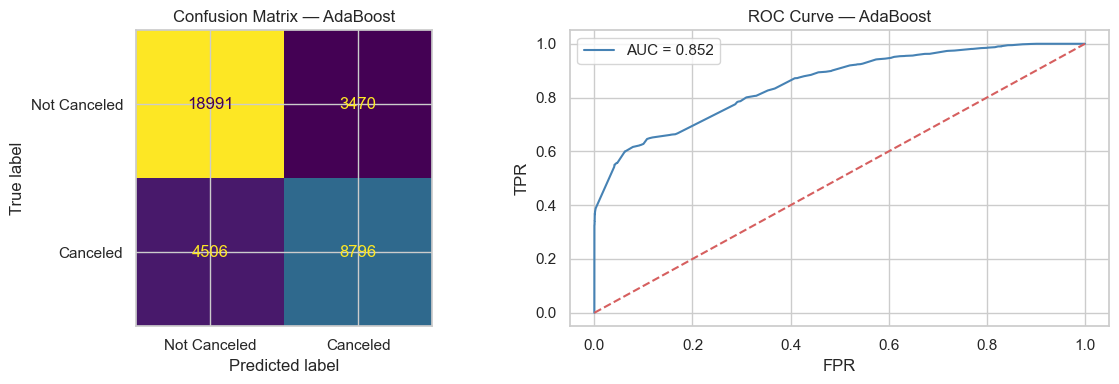

In [45]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
    n_estimators=100, random_state=SEED
)
ada.fit(X_train_res, y_train_res)
res_ada = evaluate_classifier('AdaBoost', ada, X_test, y_test)


===== Gradient Boosting =====
Accuracy : 0.8116
ROC-AUC  : 0.8814
              precision    recall  f1-score   support

Not Canceled       0.83      0.88      0.85     22461
    Canceled       0.77      0.70      0.74     13302

    accuracy                           0.81     35763
   macro avg       0.80      0.79      0.79     35763
weighted avg       0.81      0.81      0.81     35763



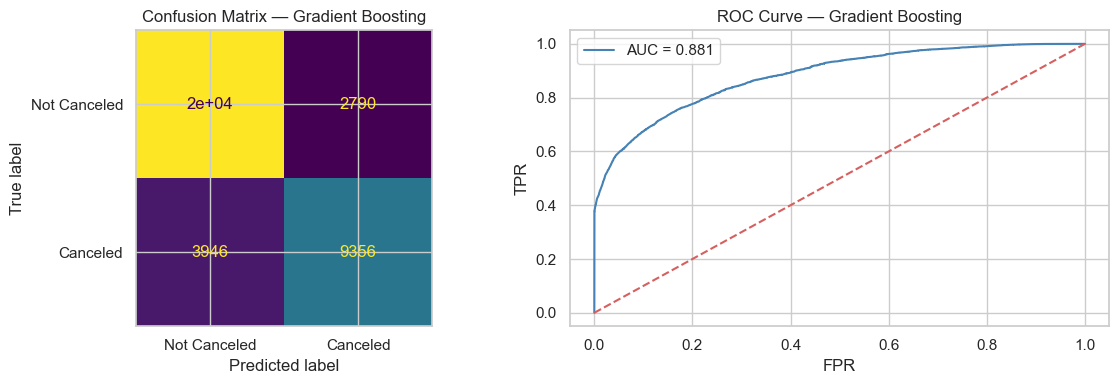

In [46]:
gb = GradientBoostingClassifier(random_state=SEED)
gb.fit(X_train_res, y_train_res)
res_gb = evaluate_classifier('Gradient Boosting', gb, X_test, y_test)


===== Neural Network (MLP) =====
Accuracy : 0.8103
ROC-AUC  : 0.8984
              precision    recall  f1-score   support

Not Canceled       0.88      0.81      0.84     22461
    Canceled       0.72      0.81      0.76     13302

    accuracy                           0.81     35763
   macro avg       0.80      0.81      0.80     35763
weighted avg       0.82      0.81      0.81     35763



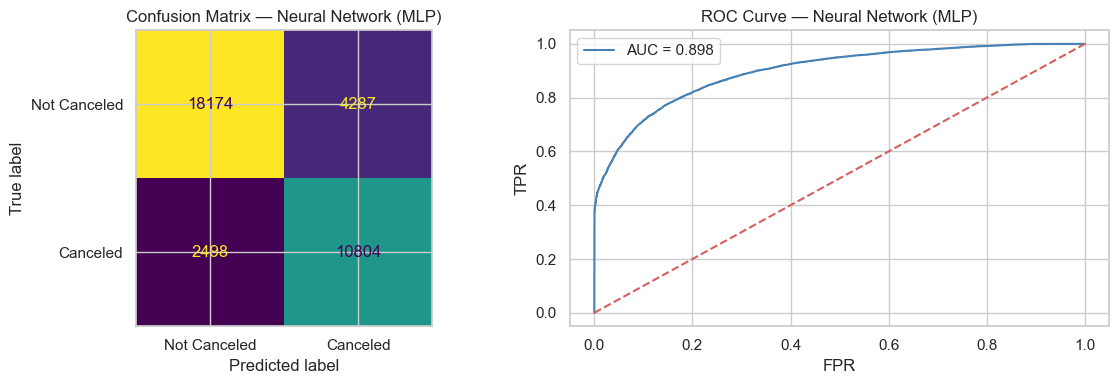

In [47]:
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=SEED))
])
mlp.fit(X_train_res, y_train_res)
res_mlp = evaluate_classifier('Neural Network (MLP)', mlp, X_test, y_test)


===== CatBoost =====
Accuracy : 0.8429
ROC-AUC  : 0.9094
              precision    recall  f1-score   support

Not Canceled       0.85      0.91      0.88     22461
    Canceled       0.83      0.73      0.78     13302

    accuracy                           0.84     35763
   macro avg       0.84      0.82      0.83     35763
weighted avg       0.84      0.84      0.84     35763



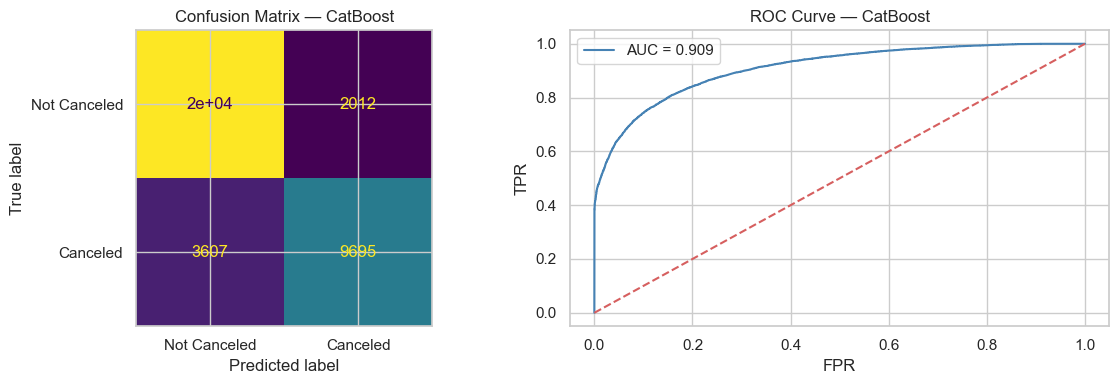

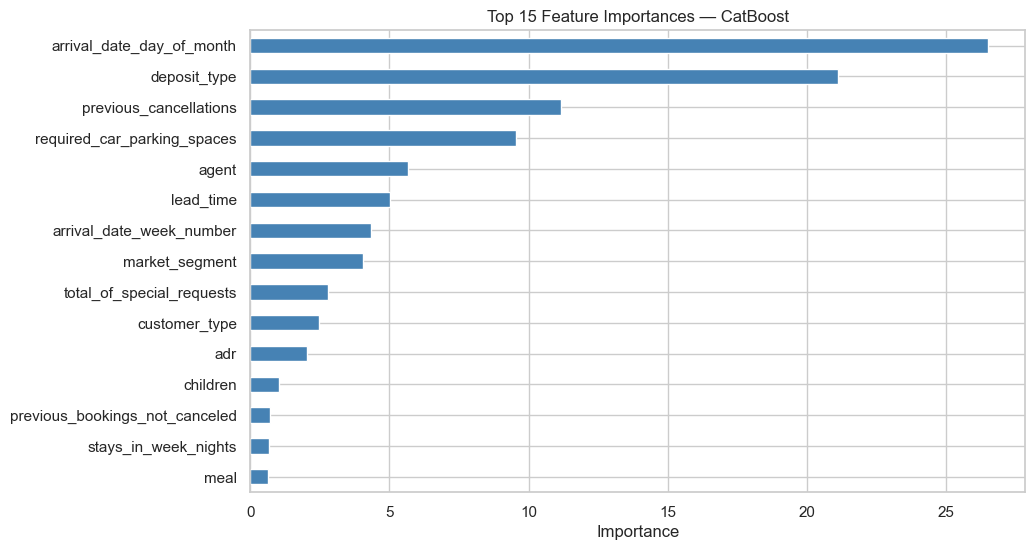

In [50]:

from catboost import CatBoostClassifier
cat = CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0)
cat.fit(X_train_res, y_train_res)
res_cat = evaluate_classifier('CatBoost', cat, X_test, y_test)
feat_imp = pd.Series(cat.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — CatBoost')
plt.xlabel('Importance')
plt.show()


                      Accuracy  ROC-AUC
Model                                  
Random Forest           0.8671   0.9338
Bagging                 0.8626   0.9290
CatBoost                0.8429   0.9094
XGBoost                 0.8304   0.9012
Neural Network (MLP)    0.8103   0.8984
Gradient Boosting       0.8116   0.8814
Decision Tree           0.8153   0.8788
AdaBoost                0.7770   0.8518
Logistic Regression     0.7704   0.8443


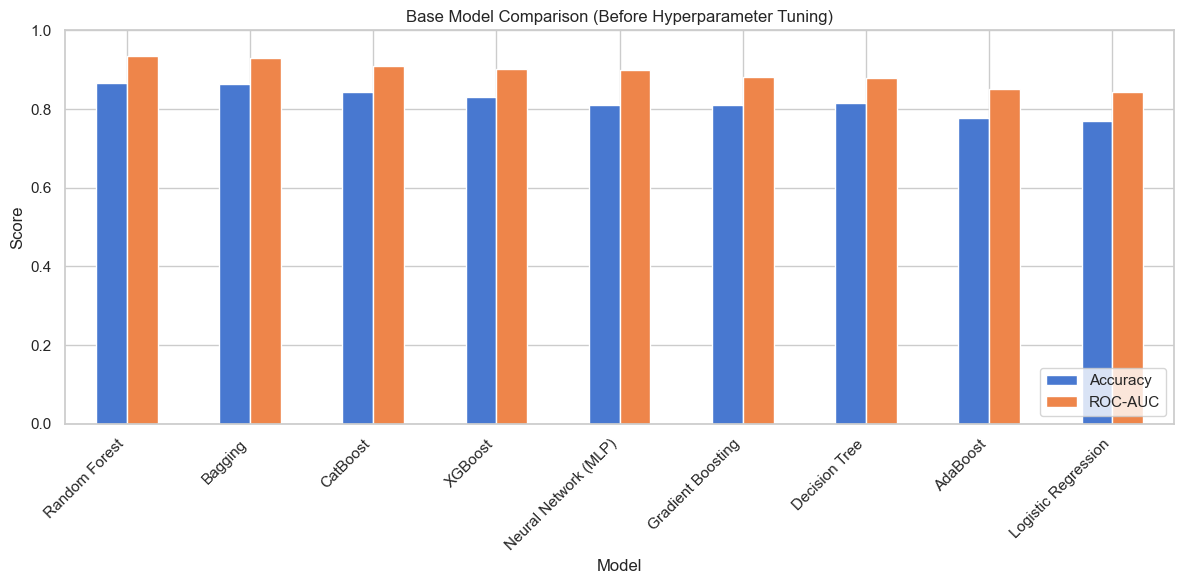

In [51]:
base_results = [res_lr, res_dt, res_rf, res_xgb, res_bagging, res_ada, res_gb, res_mlp,res_cat]

base_comparison_df = pd.DataFrame(base_results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print(base_comparison_df)

fig, ax = plt.subplots(figsize=(12, 6))
base_comparison_df[['Accuracy', 'ROC-AUC']].plot(kind='bar', ax=ax)
plt.title('Base Model Comparison (Before Hyperparameter Tuning)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best RF params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best RF ROC-AUC: 0.949

===== Random Forest (Tuned) =====
Accuracy : 0.8675
ROC-AUC  : 0.9344
              precision    recall  f1-score   support

Not Canceled       0.89      0.91      0.90     22461
    Canceled       0.83      0.80      0.82     13302

    accuracy                           0.87     35763
   macro avg       0.86      0.85      0.86     35763
weighted avg       0.87      0.87      0.87     35763



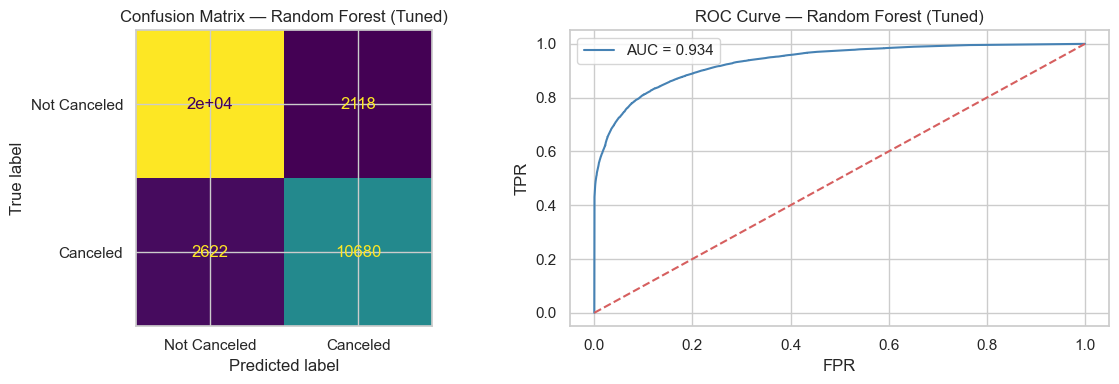

In [52]:
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_res, y_train_res)
print('Best RF params :', rf_grid.best_params_)
print('Best RF ROC-AUC:', round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
res_rf_tuned = evaluate_classifier('Random Forest (Tuned)', rf_best, X_test, y_test)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Bagging params : {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 200}
Best Bagging ROC-AUC: 0.9512

===== Bagging (Tuned) =====
Accuracy : 0.8683
ROC-AUC  : 0.9340
              precision    recall  f1-score   support

Not Canceled       0.88      0.91      0.90     22461
    Canceled       0.84      0.79      0.82     13302

    accuracy                           0.87     35763
   macro avg       0.86      0.85      0.86     35763
weighted avg       0.87      0.87      0.87     35763



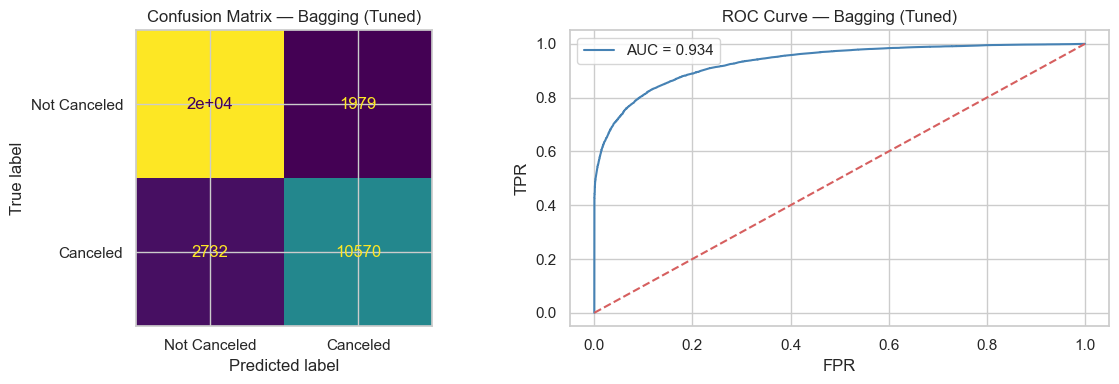

In [53]:
bagging_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples' : [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0]
}
bagging_grid = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=SEED),
        random_state=SEED,n_jobs=-1
    ),
    bagging_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
bagging_grid.fit(X_train_res, y_train_res)
print('Best Bagging params :', bagging_grid.best_params_)
print('Best Bagging ROC-AUC:', round(bagging_grid.best_score_, 4))

bagging_best = bagging_grid.best_estimator_
res_bagging_tuned = evaluate_classifier('Bagging (Tuned)', bagging_best, X_test, y_test)

## Ensemble: Voting & Stacking


===== Voting Classifier =====
Accuracy : 0.8714
ROC-AUC  : 0.9355
              precision    recall  f1-score   support

Not Canceled       0.88      0.92      0.90     22461
    Canceled       0.85      0.79      0.82     13302

    accuracy                           0.87     35763
   macro avg       0.87      0.86      0.86     35763
weighted avg       0.87      0.87      0.87     35763



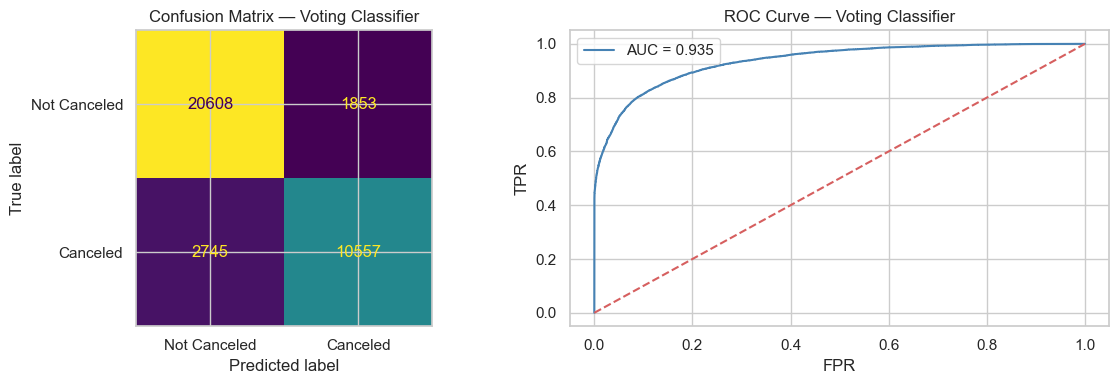

In [54]:
voting_estimators = [
    ('rf',      rf_best),
    ('bagging', bagging_best),
    ('cat',     cat),
]

voting_clf = VotingClassifier(estimators=voting_estimators, voting='soft')
voting_clf.fit(X_train_res, y_train_res)
res_voting = evaluate_classifier('Voting Classifier', voting_clf,X_test, y_test)


===== Stacking Classifier =====
Accuracy : 0.8695
ROC-AUC  : 0.9360
              precision    recall  f1-score   support

Not Canceled       0.88      0.91      0.90     22461
    Canceled       0.85      0.79      0.82     13302

    accuracy                           0.87     35763
   macro avg       0.86      0.85      0.86     35763
weighted avg       0.87      0.87      0.87     35763



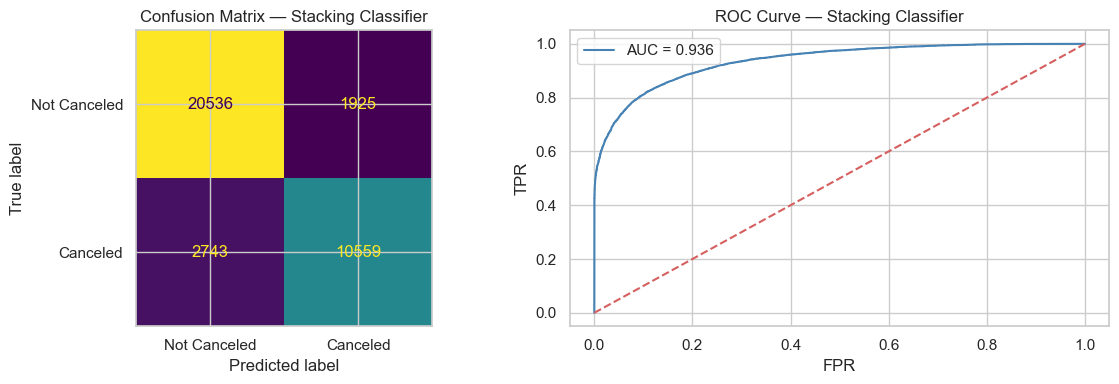

In [55]:
stacking_estimators = [
    ('rf',      rf_best),
    ('bagging', bagging_best),
    ('cat',     cat),
]

stacking_clf = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=SEED,
        n_jobs=-1
    ),
    cv=5,
    passthrough=True
)
stacking_clf.fit(X_train_res, y_train_res)
res_stacking = evaluate_classifier('Stacking Classifier', stacking_clf,X_test, y_test)

## Model Comparison

In [57]:
## Final Model Comparison

all_models = [
    ('Logistic Regression',        lr),
    ('Decision Tree',              dt),
    ('Bagging',                    bagging),
    ('Bagging (Tuned)',             bagging_best),
    ('Random Forest',              rf),
    ('Random Forest (Tuned)',       rf_best),
    ('XGBoost',                    xgb),
    ('Neural Network (MLP)',        mlp),
    ('Gradient Boosting',          gb),
    ('CatBoost',                   cat),
    ('Voting Classifier',          voting_clf),
    ('Stacking Classifier',        stacking_clf),
]

rows = []
for name, model in all_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    rep  = classification_report(y_test, y_pred, output_dict=True)
    f1   = rep['weighted avg']['f1-score']
    prec = rep['weighted avg']['precision']
    rec  = rep['weighted avg']['recall']
    rows.append({
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'ROC-AUC'  : round(roc,  4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Stacking Classifier,0.8695,0.8686,0.8695,0.8686,0.9360
Voting Classifier,0.8714,0.8706,0.8714,0.8705,0.9355
Random Forest (Tuned),0.8675,0.8667,0.8675,0.8669,0.9344
Bagging (Tuned),0.8683,0.8674,0.8683,0.8674,0.9340
Random Forest,0.8671,0.8664,0.8671,0.8665,0.9338
Bagging,0.8626,0.8621,0.8626,0.8623,0.9290
CatBoost,0.8429,0.8419,0.8429,0.8406,0.9094
XGBoost,0.8304,0.8290,0.8304,0.8293,0.9012
Neural Network (MLP),0.8103,0.8184,0.8103,0.8123,0.8984


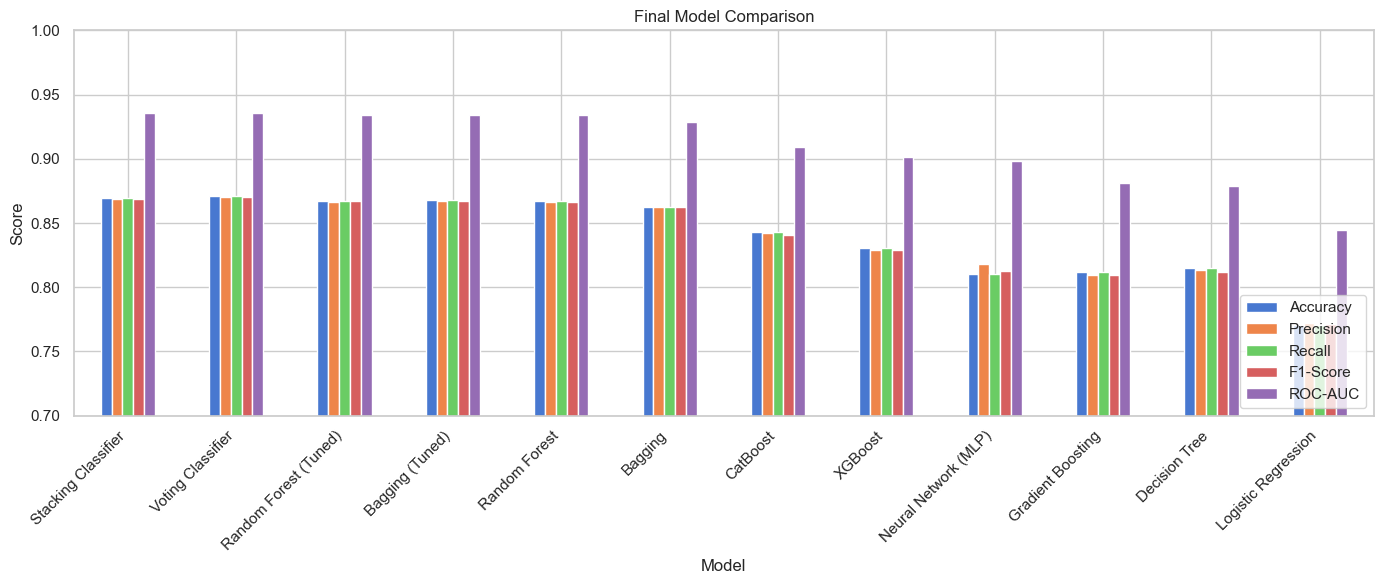

In [58]:
fig, ax = plt.subplots(figsize=(14, 6))
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', ax=ax)
plt.title('Final Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Unsupervised 

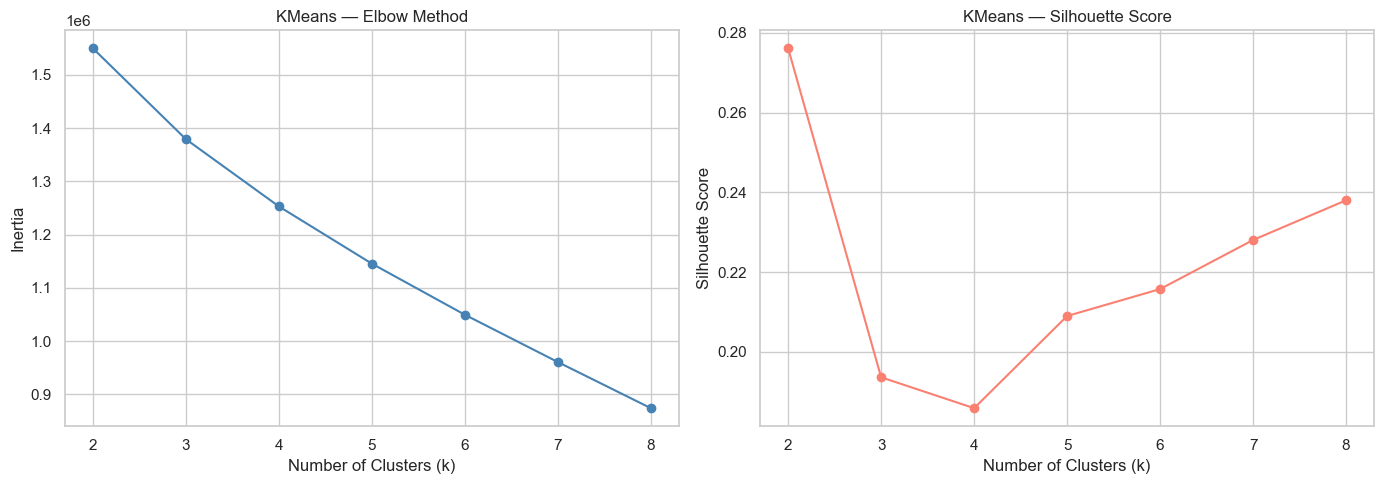

Best k by Silhouette Score: 2


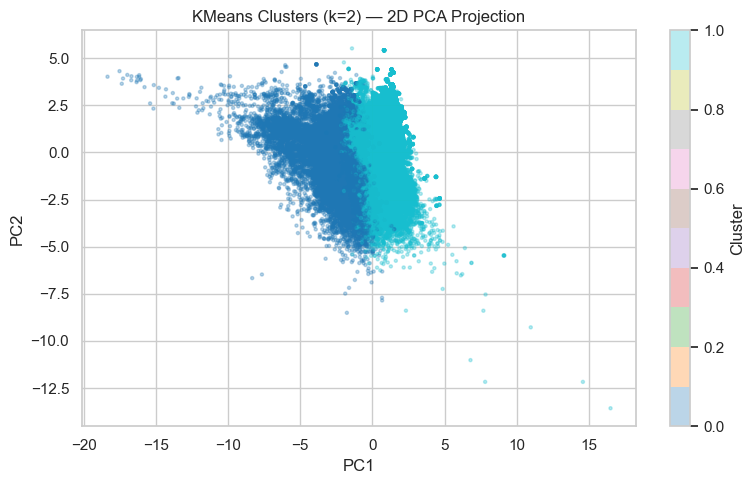

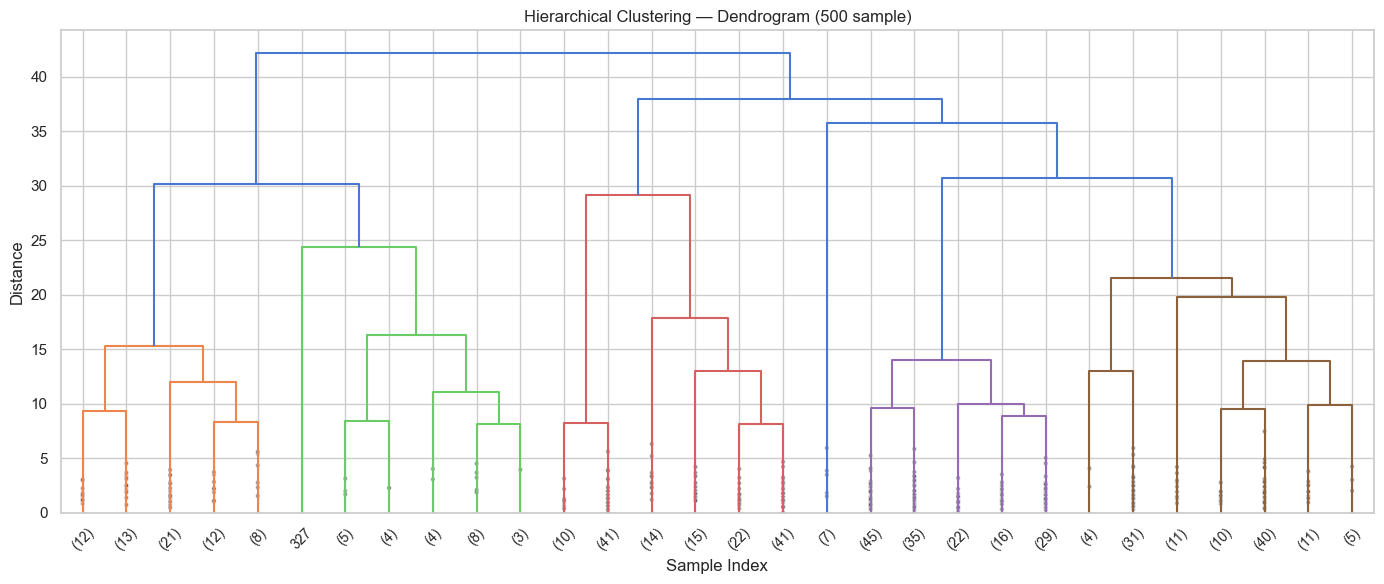

In [59]:
#Clustering
scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X)

pca_cluster = PCA(n_components=10, random_state=SEED)
X_pca = pca_cluster.fit_transform(X_scaled_cluster)

# --- KMeans: Elbow Method ---
inertia = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', color='steelblue')
axes[0].set_title('KMeans — Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='salmon')
axes[1].set_title('KMeans — Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Best k by Silhouette Score: {best_k}')

km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)

pca_2d_cluster = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d_cluster.fit_transform(X_scaled_cluster)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.3, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans Clusters (k={best_k}) — 2D PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

sample_idx = np.random.choice(len(X_pca), size=500, replace=False)
X_sample = X_pca[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering — Dendrogram (500 sample)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Logistic Regression — Mean: 0.8424 ± 0.0022
Decision Tree — Mean: 0.8768 ± 0.0015
Random Forest — Mean: 0.9335 ± 0.0009
XGBoost — Mean: 0.8997 ± 0.0016
Gradient Boosting — Mean: 0.8796 ± 0.0018
CatBoost — Mean: 0.9070 ± 0.0020
Neural Network (MLP) — Mean: 0.8983 ± 0.0010

                       CV Mean ROC-AUC  CV Std     Min     Max
Model                                                        
Random Forest                  0.9335  0.0009  0.9324  0.9347
CatBoost                       0.9070  0.0020  0.9045  0.9107
XGBoost                        0.8997  0.0016  0.8977  0.9021
Neural Network (MLP)           0.8983  0.0010  0.8970  0.8998
Gradient Boosting              0.8796  0.0018  0.8776  0.8829
Decision Tree                  0.8768  0.0015  0.8751  0.8787
Logistic Regression            0.8424  0.0022  0.8399  0.8457


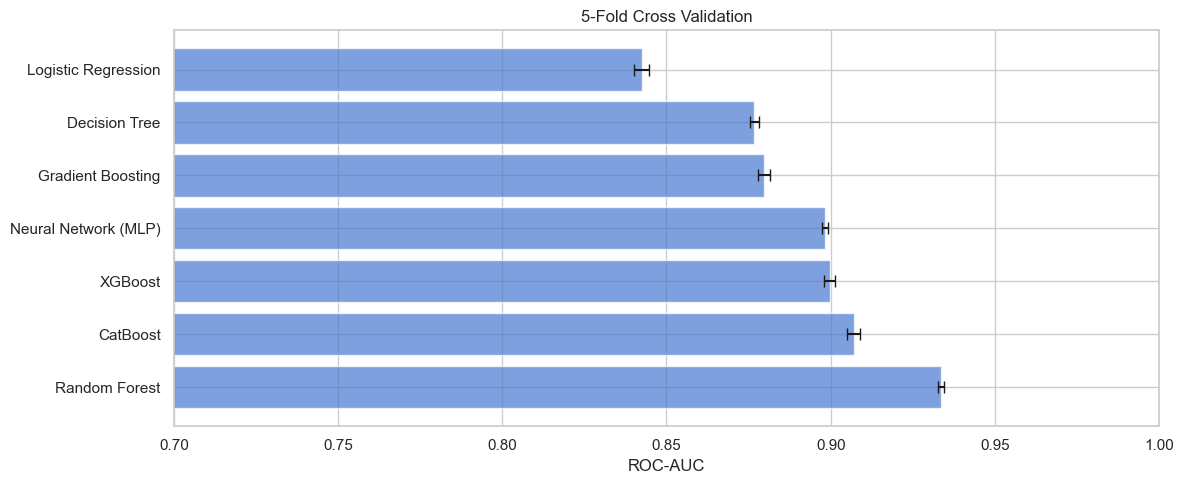

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = [
    ('Logistic Regression',  Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=SEED))])),
    ('Decision Tree',        DecisionTreeClassifier(max_depth=10, random_state=SEED)),
    ('Random Forest',        RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('XGBoost',              XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=180, random_state=SEED, eval_metric='logloss')),
    ('Gradient Boosting',    GradientBoostingClassifier(random_state=SEED)),
    ('CatBoost',             CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0)),
    ('Neural Network (MLP)', Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=SEED))])),
]

cv_rows = []
for name, model in cv_models:
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV Mean ROC-AUC': round(scores.mean(), 4),
        'CV Std':          round(scores.std(),  4),
        'Min':             round(scores.min(),  4),
        'Max':             round(scores.max(),  4),
    })
    print(f'{name} — Mean: {scores.mean():.4f} ± {scores.std():.4f}')
cv_df = pd.DataFrame(cv_rows).set_index('Model').sort_values('CV Mean ROC-AUC', ascending=False)
print('\n', cv_df)

# Plot
plt.figure(figsize=(12, 5))
plt.barh(cv_df.index, cv_df['CV Mean ROC-AUC'], 
         xerr=cv_df['CV Std'], alpha=0.7, capsize=4)
plt.xlabel('ROC-AUC')
plt.title('5-Fold Cross Validation')
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
cv_models = [
    ('Random Forest',        RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('Bagging',              XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=180, random_state=SEED, eval_metric='logloss')),
    ('Gradient Boosting',    GradientBoostingClassifier(random_state=SEED)),
    ('CatBoost',             CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0)),
    ('Neural Network (MLP)', Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=SEED))])),
]

cv_rows = []
for name, model in cv_models:
    # Wrap every model in an imblearn pipeline so SMOTE runs inside each fold
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV Mean ROC-AUC': round(scores.mean(), 4),
        'CV Std':          round(scores.std(),  4),
        'Min':             round(scores.min(),  4),
        'Max':             round(scores.max(),  4),
    })
    print(f'{name} — Mean: {scores.mean():.4f} ± {scores.std():.4f}')
cv_df = pd.DataFrame(cv_rows).set_index('Model').sort_values('CV Mean ROC-AUC', ascending=False)
print('\n', cv_df)

# Plot
plt.figure(figsize=(12, 5))
plt.barh(cv_df.index, cv_df['CV Mean ROC-AUC'], 
         xerr=cv_df['CV Std'], alpha=0.7, capsize=4)
plt.xlabel('ROC-AUC')
plt.title('5-Fold Cross Validation')
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()